In [1]:
import pandas as pd
import os

# Load all CSVs
folder = '../data/raw/calpass/'
dfs = []

for file in os.listdir(folder):
    if file.endswith('.csv'):
        temp = pd.read_csv(folder + file, skiprows=1)
        temp['college'] = file.replace('.csv', '')
        dfs.append(temp)
        print(f"{file}: {temp.shape}")

df = pd.concat(dfs, ignore_index=True)
print(f"\nCombined shape: {df.shape}")
print(df.columns.tolist())
print(df.head(3))

StudentSuccessMetrics_Degree_TransferStudents_AllanHancockCollege.csv: (17829, 18)
StudentSuccessMetrics_Degree_TransferStudents_DeAnzaCollege.csv: (17414, 18)
StudentSuccessMetrics_Degree_TransferStudents_DiabloValleyCollege.csv: (17518, 18)
StudentSuccessMetrics_Degree_TransferStudents_FoothillCollege.csv: (17721, 18)
StudentSuccessMetrics_Degree_TransferStudents_IrvineValleyCollege.csv: (17478, 18)
StudentSuccessMetrics_Degree_TransferStudents_LosAngelesCityCollege.csv: (17581, 18)
StudentSuccessMetrics_Degree_TransferStudents_MiraCostaCollege.csv: (17471, 18)
StudentSuccessMetrics_Degree_TransferStudents_Mt.SanAntonioCollege.csv: (17484, 18)
StudentSuccessMetrics_Degree_TransferStudents_OhloneCollege.csv: (17965, 18)
StudentSuccessMetrics_Degree_TransferStudents_PasadenaCityCollege.csv: (17445, 18)
StudentSuccessMetrics_Degree_TransferStudents_RiversideCityCollege.csv: (17417, 18)
StudentSuccessMetrics_Degree_TransferStudents_SacramentoCityCollege.csv: (17397, 18)
StudentSuccessMet

In [2]:
# Look at one raw file properly
raw = pd.read_csv('../data/raw/calpass/StudentSuccessMetrics_Degree_TransferStudents_DeAnzaCollege.csv', header=None)
print(raw.shape)
print(raw.iloc[:10, :8])

(17416, 17)
                 0             1         2  \
0       localeName  academicYear  metricID   
1  De Anza College          2015  SM 302SZ   
2  De Anza College          2015  SM 302SZ   
3  De Anza College          2015  SM 302SZ   
4  De Anza College          2015  SM 302SZ   
5  De Anza College          2015  SM 302SZ   
6  De Anza College          2015  SM 302SZ   
7  De Anza College          2015  SM 302SZ   
8  De Anza College          2015  SM 302SZ   
9  De Anza College          2015  SM 302SZ   

                                                3  \
0                                           title   
1  Applicants Who Enrolled in a Community College   
2  Applicants Who Enrolled in a Community College   
3  Applicants Who Enrolled in a Community College   
4  Applicants Who Enrolled in a Community College   
5  Applicants Who Enrolled in a Community College   
6  Applicants Who Enrolled in a Community College   
7  Applicants Who Enrolled in a Community College   
8  A

In [3]:
# Get proper column names from row 0
raw.columns = raw.iloc[0]
raw = raw.drop(0).reset_index(drop=True)

print(raw.columns.tolist())
print(raw['title'].unique())

['localeName', 'academicYear', 'metricID', 'title', 'description', 'source', 'categoryID', 'categoryLabel', 'disagg', 'subgroup', 'value', 'denom', 'perc', 'dataType', 'missingFlag', 'ferpaFlag', np.float64(nan)]
<ArrowStringArray>
[                             'Applicants Who Enrolled in a Community College',
                                                    'Degree/Transfer Students',
                                   'Completed Transfer-Level Math and English',
                                               'Persisted from Fall to Spring',
                     'Successfully Completed Unit Thresholds in the Fall Term',
         'Successfully Completed Quarter Unit Thresholds in the Academic Year',
                            'Transitioned to Postsecondary or Earned an Award',
 'Average No. of Units Accumulated by All First Time Associate Degree Earners',
                                      'Transferred to a Four-Year Institution',
                                       'Job Clos

In [4]:
# Load all files properly and extract transfer metric
folder = '../data/raw/calpass/'
dfs = []

for file in os.listdir(folder):
    if file.endswith('.csv'):
        temp = pd.read_csv(folder + file, header=None)
        temp.columns = temp.iloc[0]
        temp = temp.drop(0).reset_index(drop=True)
        dfs.append(temp)

df = pd.concat(dfs, ignore_index=True)

# Filter to transfer metric only
transfer = df[df['title'] == 'Transferred to a Four-Year Institution'].copy()

print(transfer.shape)
print(transfer[['localeName', 'academicYear', 'disagg', 'subgroup', 'categoryLabel', 'value', 'denom', 'perc']].head(20))
print("\nUnique disagg values:", transfer['disagg'].unique())
print("Unique categoryLabel values:", transfer['categoryLabel'].unique())

(24035, 17)
0                 localeName academicYear     disagg  \
13378  Allan Hancock College         2015    Overall   
13379  Allan Hancock College         2015        Age   
13380  Allan Hancock College         2015        Age   
13381  Allan Hancock College         2015        Age   
13382  Allan Hancock College         2015        Age   
13383  Allan Hancock College         2015        Age   
13384  Allan Hancock College         2015        Age   
13385  Allan Hancock College         2015        Age   
13386  Allan Hancock College         2015     Gender   
13387  Allan Hancock College         2015     Gender   
13388  Allan Hancock College         2015     Gender   
13389  Allan Hancock College         2015     Gender   
13390  Allan Hancock College         2015     Gender   
13391  Allan Hancock College         2015     Gender   
13392  Allan Hancock College         2015  Ethnicity   
13393  Allan Hancock College         2015  Ethnicity   
13394  Allan Hancock College        

In [5]:
import numpy as np
from sklearn.preprocessing import LabelEncoder

# Filter to CSU/UC transfers and Ethnicity disagg only
clean = transfer[
    (transfer['categoryLabel'] == 'Transferred to CSU/UC') &
    (transfer['disagg'] == 'Ethnicity')
].copy()

# Drop missing values
clean = clean.dropna(subset=['value', 'denom', 'perc'])

# Convert types
clean['value'] = pd.to_numeric(clean['value'], errors='coerce')
clean['denom'] = pd.to_numeric(clean['denom'], errors='coerce')
clean['perc'] = pd.to_numeric(clean['perc'], errors='coerce')
clean['academicYear'] = pd.to_numeric(clean['academicYear'], errors='coerce')

# Target variable: at_risk = 1 if transfer rate below statewide average (~17%)
clean['transfer_rate'] = clean['perc']
clean['at_risk'] = (clean['transfer_rate'] < 0.17).astype(int)

# Encode categoricals
le_college = LabelEncoder()
le_ethnicity = LabelEncoder()

clean['college_encoded'] = le_college.fit_transform(clean['localeName'])
clean['ethnicity_encoded'] = le_ethnicity.fit_transform(clean['subgroup'])

print(clean.shape)
print(clean[['localeName', 'academicYear', 'subgroup', 'transfer_rate', 'at_risk']].head(15))
print(f"\nAt-risk: {clean['at_risk'].sum()} / {len(clean)}")

# Save
clean.to_csv('../data/processed/transfer_clean.csv', index=False)
print("Saved!")

(847, 21)
0                 localeName  academicYear           subgroup  transfer_rate  \
13445  Allan Hancock College          2015              Asian        0.07383   
13447  Allan Hancock College          2015           Filipino        0.09302   
13448  Allan Hancock College          2015           Hispanic        0.04543   
13450  Allan Hancock College          2015              White        0.05530   
13454  Allan Hancock College          2015  All Masked Values        0.02867   
13652  Allan Hancock College          2016              Asian        0.10063   
13654  Allan Hancock College          2016           Filipino        0.05854   
13655  Allan Hancock College          2016           Hispanic        0.04071   
13657  Allan Hancock College          2016              White        0.05259   
13658  Allan Hancock College          2016  Two or More Races        0.04605   
13661  Allan Hancock College          2016  All Masked Values        0.02244   
13857  Allan Hancock College  

In [6]:
# Better target: is this ethnicity group below the college-year average?
college_avg = clean.groupby(['localeName', 'academicYear'])['transfer_rate'].transform('mean')
clean['at_risk'] = (clean['transfer_rate'] < college_avg).astype(int)

print(f"At-risk: {clean['at_risk'].sum()} / {len(clean)}")
print(f"Class balance: {clean['at_risk'].mean():.2f}")

# Feature set
features = ['college_encoded', 'ethnicity_encoded', 'academicYear', 'denom']
X = clean[features]
y = clean['at_risk']

print("\nFeature matrix shape:", X.shape)
print(X.head())

# Resave
clean.to_csv('../data/processed/transfer_clean.csv', index=False)
print("Resaved!")

At-risk: 404 / 847
Class balance: 0.48

Feature matrix shape: (847, 4)
0      college_encoded  ethnicity_encoded  academicYear  denom
13445                0                  2          2015    149
13447                0                  4          2015    172
13448                0                  5          2015   4556
13450                0                  9          2015   2604
13454                0                  0          2015    593
Resaved!


In [7]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
import joblib

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

joblib.dump(model, '../src/model.pkl')
print("Model saved!")

Accuracy: 0.8294

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.84      0.84        89
           1       0.82      0.81      0.82        81

    accuracy                           0.83       170
   macro avg       0.83      0.83      0.83       170
weighted avg       0.83      0.83      0.83       170

Model saved!


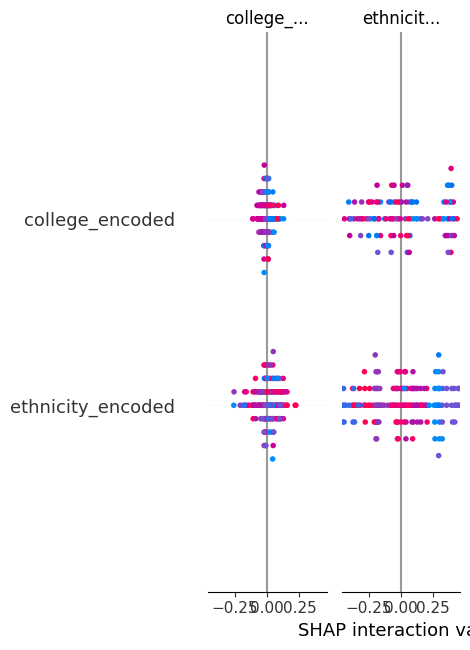

Saved!


In [8]:
import shap
import matplotlib.pyplot as plt

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test, feature_names=features, show=False)
plt.tight_layout()
plt.savefig('../src/shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved!")

In [9]:
import streamlit as st
import pandas as pd
import plotly.express as px
import joblib
import numpy as np
from PIL import Image
import os
from sklearn.preprocessing import LabelEncoder

st.set_page_config(page_title="CA Transfer Outcome Predictor", layout="wide")

APP_DIR = os.path.dirname(os.path.abspath(__file__))

@st.cache_data
def load_data():
    return pd.read_csv(os.path.join(APP_DIR, 'transfer_clean.csv'))

@st.cache_resource
def load_model():
    return joblib.load(os.path.join(APP_DIR, 'model.pkl'))

df = load_data()
model = load_model()

# Encoders
le_college = LabelEncoder().fit(df['localeName'])
le_ethnicity = LabelEncoder().fit(df['subgroup'])

st.title("🎓 CA Transfer Outcome Predictor")
st.markdown("Predicting UC/CSU transfer equity gaps across California community colleges using CCCCO data.")

# Sidebar
st.sidebar.header("Filters")
year = st.sidebar.selectbox("Academic Year", sorted(df['academicYear'].unique(), reverse=True))
college = st.sidebar.multiselect("College", sorted(df['localeName'].unique()), default=[])

filtered = df[df['academicYear'] == year]
if college:
    filtered = filtered[filtered['localeName'].isin(college)]

# Metrics
col1, col2, col3 = st.columns(3)
col1.metric("Total Records", len(filtered))
col2.metric("At-Risk Groups", filtered['at_risk'].sum())
col3.metric("Avg Transfer Rate", f"{filtered['transfer_rate'].mean()*100:.1f}%")

# Bar chart by ethnicity
st.subheader("📊 Transfer Rate by Ethnicity")
eth_avg = filtered.groupby('subgroup')['transfer_rate'].mean().reset_index()
eth_avg.columns = ['Ethnicity', 'Transfer Rate']
eth_avg = eth_avg.sort_values('Transfer Rate', ascending=True)
fig = px.bar(eth_avg, x='Transfer Rate', y='Ethnicity', orientation='h',
             color='Transfer Rate', color_continuous_scale='RdYlGn',
             height=400)
st.plotly_chart(fig, use_container_width=True)

# Transfer rate by college
st.subheader("🏫 Transfer Rate by College")
col_avg = filtered.groupby('localeName')['transfer_rate'].mean().reset_index()
col_avg.columns = ['College', 'Transfer Rate']
col_avg = col_avg.sort_values('Transfer Rate', ascending=True)
fig2 = px.bar(col_avg, x='Transfer Rate', y='College', orientation='h',
              color='Transfer Rate', color_continuous_scale='RdYlGn',
              height=500)
st.plotly_chart(fig2, use_container_width=True)

# SHAP
st.subheader("🔍 Feature Importance (SHAP)")
shap_img = Image.open(os.path.join(APP_DIR, 'shap_summary.png'))
st.image(shap_img, use_container_width=True)

# Risk table
st.subheader("📋 At-Risk Groups Table")
st.dataframe(
    filtered[['localeName', 'subgroup', 'academicYear', 'transfer_rate', 'at_risk']]
    .sort_values('transfer_rate')
    .reset_index(drop=True),
    use_container_width=True
)

# Prediction tool
st.subheader("⚡ Predict Transfer Risk")
col1, col2 = st.columns(2)
with col1:
    college_input = st.selectbox("College", sorted(df['localeName'].unique()))
    ethnicity_input = st.selectbox("Ethnicity", sorted(df['subgroup'].unique()))
with col2:
    year_input = st.selectbox("Year", sorted(df['academicYear'].unique()))
    denom_input = st.number_input("Student Group Size", min_value=1, value=200)

if st.button("Predict Risk"):
    input_data = np.array([[
        le_college.transform([college_input])[0],
        le_ethnicity.transform([ethnicity_input])[0],
        year_input,
        denom_input
    ]])
    pred = model.predict(input_data)[0]
    prob = model.predict_proba(input_data)[0][1]

    if pred == 1:
        st.error(f"⚠️ AT RISK — {prob*100:.1f}% probability of below-average transfer rate")
    else:
        st.success(f"✅ ON TRACK — {prob*100:.1f}% risk score")

2026-04-21 02:15:52.553 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


NameError: name '__file__' is not defined